## Uppal (2025) – Dual-Layer Equivalent Sources Method

In this notebook, we apply the dual-layer equivalent sources method proposed by [Uppal (2025)](https://github.com/compgeolab/eqs-gb-norm-of-b).  
This approach is designed to capture both the long- and short-wavelength components of the data.


In [2]:
import os
import pygmt
import pooch
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import bordado as bd
import boule as bl
import harmonica as hm
import verde as vd
import itertools
from scipy.interpolate import griddata

import spherical as sph

Import the real data to create our synthetic.

In [3]:
caminho = "../data/parana-basin-magnetic-processed.csv"

df = pd.read_csv(caminho, sep=',', comment="#")
df.columns = ['FID','ESTACAO','LINHA','X','Y','LATITUDE','LONGITUDE','DATA','HORA','GPSALT','BARO','MAGBRU','MAGCOM','MAGBASE','MAGCOR','MAGNIV','MAGMIC','MAGIGRF','IGRF','MDT']

lat = df['LATITUDE']
lon = df['LONGITUDE']
height = df["GPSALT"].values

Reduce the data so we can run faster.

In [4]:
reducer = vd.BlockReduce(reduction=np.median, spacing= 0.2)

coordinates, height_new = reducer.filter(
    (df.LONGITUDE, df.LATITUDE), df.GPSALT
)
lon, lat = coordinates

coordinates = (lon, lat, height_new)
coordinates_real = (df['LONGITUDE'], df['LATITUDE'], df["GPSALT"].values)

print(coordinates[0].size)
print(coordinates_real[0].size)

/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.12/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7f4fd43ff380> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.12/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7f4fd43ff380> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


1777
2256991


Ignore the real data anda create our synthetic sources and regional.

In [5]:
inclination, declination = -25, -20  

#Source 1 
source1a, _ = bd.profile_coordinates((-57,-14),(-54,-15.5),size= 1000, non_dimensional_coords= - 30e3)
magnetic_moment1a = hm.magnetic_angles_to_vec(np.full(1000, 7e10), np.full(1000, inclination),np.full(1000, declination))

source1b, _ = bd.profile_coordinates((-57,-16),(-48,-13),size= 1000,non_dimensional_coords=  - 30e3)
magnetic_moment1b = hm.magnetic_angles_to_vec(np.full(1000, 7e10), np.full(1000, inclination),np.full(1000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source1a, source1b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment1a, magnetic_moment1b)]

#Source 2 
source2a, _= bd.profile_coordinates((-52,-16),(-53,-16),size= 300,non_dimensional_coords=  - 25e3)
magnetic_moment2a = hm.magnetic_angles_to_vec(np.full(300, 6e10), np.full(300, inclination),np.full(300, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source2a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment2a)]

source2b, _= bd.profile_coordinates((-54,-16.7),(-53,-16.7), size= 300,non_dimensional_coords= - 22e3)
magnetic_moment2b = hm.magnetic_angles_to_vec(np.full(300, 6e10), np.full(300, inclination),np.full(300, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source2b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment2b)]

#Source 3
source3, _= bd.profile_coordinates((-54,-17.5),(-54.5,-17.5),size= 150,non_dimensional_coords=  - 20e3)
magnetic_moment3 = hm.magnetic_angles_to_vec(np.full(150, 6e10), np.full(150, inclination),np.full(150, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source3)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment3)]

#Source 4
source4a, _= bd.profile_coordinates((-54,-20),(-53.5,-19),size= 250, non_dimensional_coords= - 17e3)
magnetic_moment4a = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source4a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment4a)]

source4b, _= bd.profile_coordinates((-54.5,-19.5),(-54,-18.5),size= 250,non_dimensional_coords=  - 16e3)
magnetic_moment4b = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source4b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment4b)]

source4c, _= bd.profile_coordinates((-54.6,-20.3),(-54.6,-20.4),size= 100,non_dimensional_coords=  - 13e3)
magnetic_moment4c = hm.magnetic_angles_to_vec(np.full(100, 6e10), np.full(100, inclination),np.full(100, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source4c)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment4c)]

#Source 5
source5a, _= bd.profile_coordinates((-52,-19),(-49,-19),size= 250,non_dimensional_coords=  - 15e3)
magnetic_moment5a = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5a)]

source5b, _= bd.profile_coordinates((-50,-19.6),(-48,-19.6),size= 250,non_dimensional_coords=  - 14e3)
magnetic_moment5b = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5b)]

source5c, _= bd.profile_coordinates((-48,-20),(-45,-20),size= 250,non_dimensional_coords= - 15e3)
magnetic_moment5c = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5c)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5c)]

source5d, _= bd.profile_coordinates((-45,-20.4),(-48,-20.4),size= 250,non_dimensional_coords=  - 13e3)
magnetic_moment5d = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5d)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5d)]

source5e, _= bd.profile_coordinates((-45,-20.9),(-48,-20.9),size= 250,non_dimensional_coords=  - 12e3)
magnetic_moment5e = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5e)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5e)]

source5f, _= bd.profile_coordinates((-45,-13),(-52,-18.9),size= 500,non_dimensional_coords=  - 11e3)
magnetic_moment5f = hm.magnetic_angles_to_vec(np.full(500, 6e10), np.full(500, inclination),np.full(500, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5f)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5f)]

source5g= vd.scatter_points(region= (-52.3,-52.3,-19.6,-19.6), size= 1, extra_coords=   - 12e3)
magnetic_moment5g = hm.magnetic_angles_to_vec(np.full(1,8e11), np.full(1,45), np.full(1,0))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5g)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5g)]

#Source 6
source6a, _= bd.profile_coordinates((-48,-20.9),(-51,-23.9),size= 250,non_dimensional_coords=  - 15e3)
magnetic_moment6a = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source6a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment6a)]

source6b, _= bd.profile_coordinates((-47,-20.9),(-50,-24.9),size= 250,non_dimensional_coords=  - 14e3)
magnetic_moment6b = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source6b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment6b)]

source6c, _= bd.profile_coordinates((-51.4,-22),(-50.2,-21),size=250,non_dimensional_coords= - 13e3)
magnetic_moment6c = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source6c)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment6c)]

#Source 7
source7a, _= bd.profile_coordinates((-52,-16),(-53.8,-21),size= 250,non_dimensional_coords= - 12e3)
magnetic_moment7a = hm.magnetic_angles_to_vec(np.full(250, -6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source7a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment7a)]

#Source 8 
source8a, _= bd.profile_coordinates((-57,-26.5),(-54,-23.1),size= 400,non_dimensional_coords=  - 15e3)
magnetic_moment8a = hm.magnetic_angles_to_vec(np.full(400, -9e10), np.full(400, inclination),np.full(400, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source8a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment8a)]


#Source 9
source9a, _= bd.profile_coordinates((-48,-26.5),(-54,-22),size= 5000,non_dimensional_coords=  - 6e3)
magnetic_moment9a = hm.magnetic_angles_to_vec(np.full(5000, -6e8), np.full(5000, inclination),np.full(5000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source9a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment9a)]

source9b, _= bd.profile_coordinates((-46.5,-26.4),(-51.5,-22.2),size= 5000, non_dimensional_coords= - 3e3)
magnetic_moment9b = hm.magnetic_angles_to_vec(np.full(5000, -6e8), np.full(5000, inclination),np.full(5000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source9b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment9b)]

source9c, _= bd.profile_coordinates((-48,-26.6),(-51,-22.5),size= 5000,non_dimensional_coords=  - 5e3)
magnetic_moment9c = hm.magnetic_angles_to_vec(np.full(5000, -6e8), np.full(5000, inclination),np.full(5000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source9c)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment9c)]

source9d, _= bd.profile_coordinates((-51.4,-19),(-45,-26.5),size= 5000,non_dimensional_coords=  - 4e3)
magnetic_moment9d = hm.magnetic_angles_to_vec(np.full(5000, -6e8), np.full(5000, inclination),np.full(5000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source9d)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment9d)]

#Regional Field
regional= vd.scatter_points(region=(-55,-50,-23,-17), size=90, extra_coords=-60e3, random_state=1)
magnetic_moment_reg = hm.magnetic_angles_to_vec(np.full(90, -9e12), np.full(90, -90),np.full(90, 45))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, regional)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment_reg)]

In [6]:
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source_coordinates, magnetic_moment)
magnetic_anomaly = hm.total_field_anomaly(magnetic_field, inclination, declination)


#Random noise

noise_level =  0.01 * vd.maxabs(magnetic_anomaly)

magnetic_anomaly += np.random.default_rng(42).normal(
    0, noise_level, size=magnetic_anomaly.shape
)

(np.float64(-56.9182934385),
 np.float64(-46.4666293915),
 np.float64(-24.7923095875),
 np.float64(-13.6286160025))

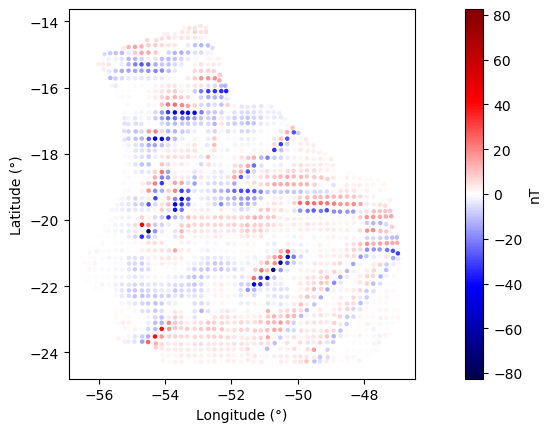

In [7]:
scale = vd.maxabs(magnetic_anomaly)
plt.scatter(coordinates[0], coordinates[1],  c = magnetic_anomaly, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

Use our function to create a grid of true total field anomaly.

In [8]:
grid_coord = vd.grid_coordinates((-56.5, -47, -25, -14), shape=(150, 150), extra_coords= 500)

magnetic_field_grid = sph.dipole_magnetic_geodetic(grid_coord, source_coordinates, magnetic_moment)
grided_dd_anomaly = hm.total_field_anomaly(magnetic_field_grid, inclination, declination)

# Deep equivalent sources
Use a block reduce method to create our deep equivalent sources.

In [9]:
reducer = vd.BlockReduce(reduction=np.mean, spacing=0.3,  center_coordinates=False, drop_coords=False)
blocked_deep_equivalent_sources, magnetic_anomaly_reduced = reducer.filter(coordinates, magnetic_anomaly)

print(blocked_deep_equivalent_sources[0].size)

778


/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.12/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function mean at 0x7f4fd77e5940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.12/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function mean at 0x7f4fd77e5940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


Plot the data so we can visualize the reduced version.

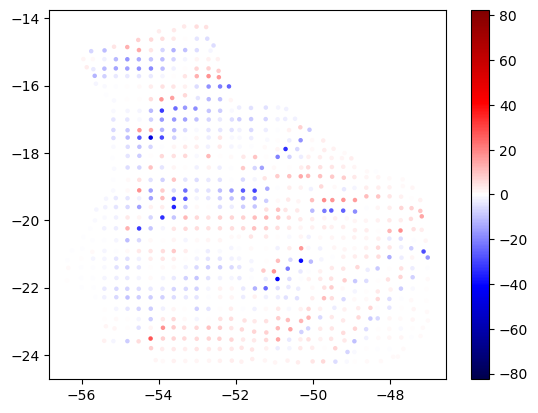

In [10]:
plt.scatter(*blocked_deep_equivalent_sources[:2], c = magnetic_anomaly_reduced,s = 5, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar()

In [11]:
def estimate_depth(coordinates):
        """
        Estimate a reasonable depth if one isn't given.
        """
        ellipsoid=bl.WGS84

        coslat = np.cos(np.radians(coordinates[1]))
        sinlat = np.sin(np.radians(coordinates[1]))
        N = ellipsoid.prime_vertical_radius(sinlat)
        b = ellipsoid.semiminor_axis
        a = ellipsoid.semimajor_axis
        coordinates_cartesian = (
            (N + coordinates[2]) * coslat * np.cos(np.radians(coordinates[0])),
            (N + coordinates[2]) * coslat * np.sin(np.radians(coordinates[0])),
            (b**2 * N / a**2 + coordinates[2]) * sinlat,
        )
        return bd.neighbor_distance_statistics(coordinates_cartesian, "median", k=10)

Do the croos validation to fit the best equivalent souce

In [12]:
damping_deep = [1e-1, 1e1, 1e2, 1e3,1e4,1e5, 1e6]
depths = np.mean(estimate_depth(blocked_deep_equivalent_sources))
source_depth_deep = [depths, depths*1.25,depths*2.5, depths*4.25]
parameter_sets_deep = [
    dict(damping=combo[0], depth=combo[1])
    for combo in itertools.product(damping_deep, source_depth_deep)
]
print("Number of combinations:", len(parameter_sets_deep))

Number of combinations: 28


In [13]:
%%time
kfold = vd.BlockKFold(
    spacing=0.5,
    shuffle=True,
    random_state=0,
    balance=True,
)
features = np.transpose(blocked_deep_equivalent_sources[:2])
scores_deep = []
damping_deep = []
source_depth_deep = []
for parameters in parameter_sets_deep:    
    print(parameters)
    eqs_deep = sph.EquivalentSourcesMagGeod(**parameters)
    tmp = []
    for train, test in kfold.split(features):
        eqs_deep.fit(
            [c[train] for c in blocked_deep_equivalent_sources],
            inclination, 
            declination,
            magnetic_anomaly_reduced[train] 
        )
        predicted = hm.total_field_anomaly(
            eqs_deep.predict([c[test] for c in blocked_deep_equivalent_sources]),
            inclination, declination
        )
        tmp.append(np.linalg.norm(magnetic_anomaly_reduced[test] - predicted))
    scores_deep.append(np.mean(tmp))
    damping_deep.append(parameters['damping'])
    source_depth_deep.append(parameters['depth'])
best = np.argmin(scores_deep)
parameter_sets_deep[best]

{'damping': 0.1, 'depth': np.float64(44613.16256531912)}
{'damping': 0.1, 'depth': np.float64(55766.453206648905)}
{'damping': 0.1, 'depth': np.float64(111532.90641329781)}
{'damping': 0.1, 'depth': np.float64(189605.94090260626)}
{'damping': 10.0, 'depth': np.float64(44613.16256531912)}
{'damping': 10.0, 'depth': np.float64(55766.453206648905)}
{'damping': 10.0, 'depth': np.float64(111532.90641329781)}
{'damping': 10.0, 'depth': np.float64(189605.94090260626)}
{'damping': 100.0, 'depth': np.float64(44613.16256531912)}
{'damping': 100.0, 'depth': np.float64(55766.453206648905)}
{'damping': 100.0, 'depth': np.float64(111532.90641329781)}
{'damping': 100.0, 'depth': np.float64(189605.94090260626)}
{'damping': 1000.0, 'depth': np.float64(44613.16256531912)}
{'damping': 1000.0, 'depth': np.float64(55766.453206648905)}
{'damping': 1000.0, 'depth': np.float64(111532.90641329781)}
{'damping': 1000.0, 'depth': np.float64(189605.94090260626)}
{'damping': 10000.0, 'depth': np.float64(44613.16256

{'damping': 100.0, 'depth': np.float64(111532.90641329781)}

Best parameters: {'damping': 100.0, 'depth': np.float64(111532.90641329781)}
Best RMSE: 88.012 nT


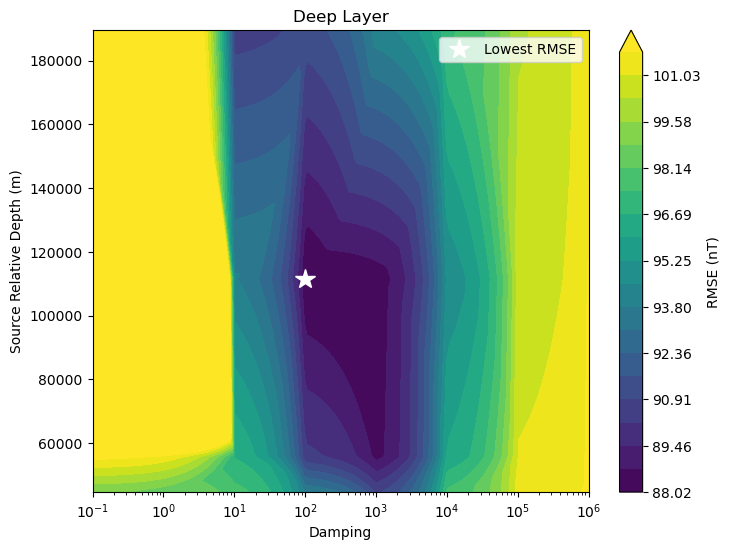

In [14]:
damping_values_deep = np.array(damping_deep)
depth_values_deep = np.array(source_depth_deep)
score_values_deep = np.array(scores_deep)

best_deep = np.argmin(score_values_deep)
best_damping_deep = damping_values_deep[best_deep]
best_depth_deep = depth_values_deep[best_deep]
best_rmse_deep = score_values_deep[best_deep]
best_params_deep = parameter_sets_deep[best_deep]
print("Best parameters:", best_params_deep)
print(f"Best RMSE: {best_rmse_deep:.3f} nT")

x_deep = np.logspace(np.log10(damping_values_deep.min()), np.log10(damping_values_deep.max()), 200)
y_deep = np.linspace(depth_values_deep.min(), depth_values_deep.max(), 200)
X_deep, Y_deep = np.meshgrid(x_deep, y_deep)
Z_deep = griddata(
    (damping_values_deep, depth_values_deep),
    score_values_deep,
    (X_deep, Y_deep),
    method='linear',
)

plt.figure(figsize=(8, 6))
levels_deep = np.linspace(
    Z_deep.min(),
    np.nanpercentile(score_values_deep, 80),
    20,
)
c = plt.contourf(
    X_deep,
    Y_deep,
    Z_deep,
    levels=levels_deep,
    cmap="viridis",
    extend='max',
)
plt.plot(
    best_damping_deep,
    best_depth_deep,
    '*',
    color='white',
    markersize=15,
    label='Lowest RMSE'
)
plt.xscale('log')
plt.xlabel('Damping')
plt.ylabel('Source Relative Depth (m)')
plt.colorbar(c, label='RMSE (nT)')
plt.legend()
plt.title("Deep Layer")
plt.show()

Run the inversion of the deep equivalent sources with the values obtained with the cross-validation.

In [15]:
%%time
eqs_deep = sph.EquivalentSourcesMagGeod(**parameter_sets_deep[best])
eqs_deep.fit(blocked_deep_equivalent_sources, inclination, declination, magnetic_anomaly_reduced)


CPU times: user 533 ms, sys: 0 ns, total: 533 ms
Wall time: 139 ms


Predict the deep equivalent sources and calculate the residuals.

In [16]:
predicted_deep =  hm.total_field_anomaly(eqs_deep.predict(coordinates), inclination, declination)
residuals_deep = magnetic_anomaly - predicted_deep 
predicted_b_deep = eqs_deep.predict(coordinates)

predicted_blocked_deep = eqs_deep.predict(blocked_deep_equivalent_sources)

residuals_be_deep = magnetic_field[0].ravel() - predicted_b_deep[0]
residuals_bn_deep = magnetic_field[1].ravel() - predicted_b_deep[1]
residuals_bu_deep = magnetic_field[2].ravel() - predicted_b_deep[2]

Plot the predidted and the residuals of the deep layer, to check if the EQS is good.

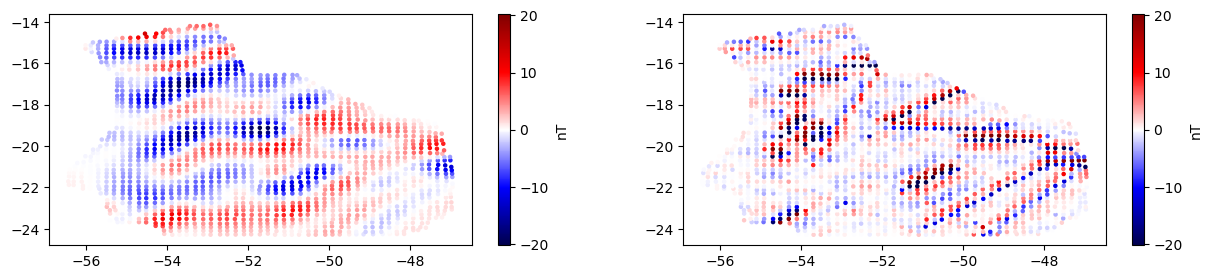

In [17]:
scale_deep = vd.maxabs(predicted_deep)
plt.figure(figsize=(15,3))


plt.subplot(1,2,1)
plt.scatter(coordinates[0], coordinates[1],c = predicted_deep, s = 5,cmap="seismic", vmin=-scale_deep, vmax=scale_deep)
plt.colorbar(label='nT')

plt.subplot(1,2,2)
plt.scatter(coordinates[0], coordinates[1],c = residuals_deep, s = 5,cmap="seismic", vmin=-scale_deep, vmax=scale_deep)
plt.colorbar(label='nT')

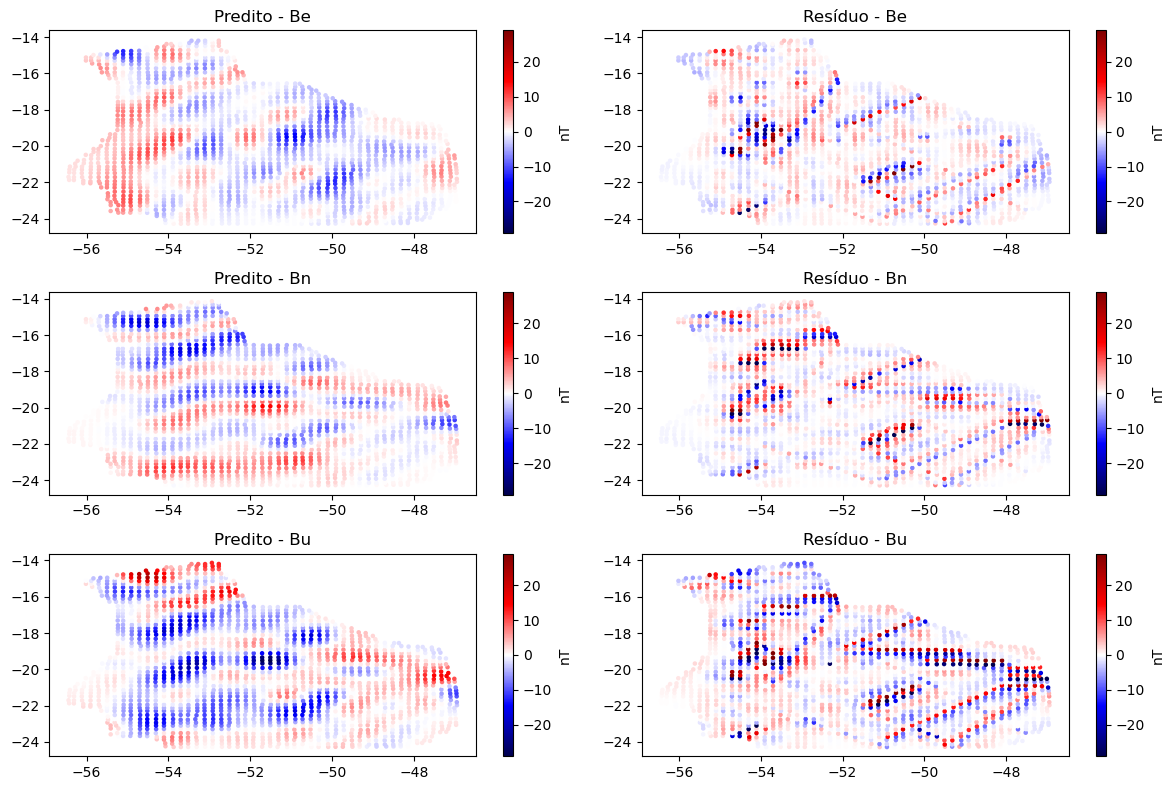

In [18]:
scale_b_deep = vd.maxabs(predicted_b_deep)
plt.figure(figsize=(12, 8))

plt.subplot(3, 2, 1)
plt.scatter(coordinates[0], coordinates[1], c=predicted_b_deep[0], s=5,
            cmap="seismic", vmin=-scale_b_deep, vmax=scale_b_deep)
plt.colorbar(label='nT')
plt.title("Predito - Be")

plt.subplot(3, 2, 2)
plt.scatter(coordinates[0], coordinates[1], c=residuals_be_deep, s=5,
            cmap="seismic", vmin=-scale_b_deep, vmax=scale_b_deep)
plt.colorbar(label='nT')
plt.title("Resíduo - Be")

plt.subplot(3, 2, 3)
plt.scatter(coordinates[0], coordinates[1], c=predicted_b_deep[1], s=5,
            cmap="seismic", vmin=-scale_b_deep, vmax=scale_b_deep)
plt.colorbar(label='nT')
plt.title("Predito - Bn")

plt.subplot(3, 2, 4)
plt.scatter(coordinates[0], coordinates[1], c=residuals_bn_deep, s=5,
            cmap="seismic", vmin=-scale_b_deep, vmax=scale_b_deep)
plt.colorbar(label='nT')
plt.title("Resíduo - Bn")

plt.subplot(3, 2, 5)
plt.scatter(coordinates[0], coordinates[1], c=predicted_b_deep[2], s=5,
            cmap="seismic", vmin=-scale_b_deep, vmax=scale_b_deep)
plt.colorbar(label='nT')
plt.title("Predito - Bu")

plt.subplot(3, 2, 6)
plt.scatter(coordinates[0], coordinates[1], c=residuals_bu_deep, s=5,
            cmap="seismic", vmin=-scale_b_deep, vmax=scale_b_deep)
plt.colorbar(label='nT')
plt.title("Resíduo - Bu")

plt.tight_layout()
plt.show()

# Shallow equivalent sources
Use the gradient-boosted method to generate our shallow equivalent sources.

In [19]:
dampings_shallow = [1e-5,1e-2,1e0,1e2, 1e5]
depths_shallow = [23e3,25e3, 27e3, 29e3, 31e3]
parameter_sets_shallow = [
    dict(damping=combo[0], depth=combo[1])
    for combo in itertools.product(dampings_shallow, depths_shallow)
] 
print("Number of combinations:", len(parameter_sets_shallow))

Number of combinations: 25


In [20]:
%%time
kfold = vd.BlockKFold(
    spacing=1,
    shuffle=True,
    random_state=0,
    balance=True,
)
features = np.transpose(coordinates[:2])
scores_shallow = []
damping_shallow = []
source_depth_shallow = []
for parameters in parameter_sets_shallow:    
    print(parameters)
    eqs_shallow = sph.EquivalentSourcesMagGeodGB(verbose=False,window_size=200e3,**parameters)
    tmp = []
    for train, test in kfold.split(features):
        eqs_shallow.fit(
            [c[train] for c in coordinates],  
            inclination,declination,
            residuals_deep[train],
        )
        predicted = hm.total_field_anomaly(
            eqs_shallow.predict([c[test] for c in coordinates]),
            inclination,declination,
        )
        tmp.append(np.linalg.norm(residuals_deep[test] - predicted))
    scores_shallow.append(np.mean(tmp))
    damping_shallow.append(parameters['damping'])
    source_depth_shallow.append(parameters['depth'])
best = np.argmin(scores_shallow)
parameter_sets_shallow[best]

{'damping': 1e-05, 'depth': 23000.0}
{'damping': 1e-05, 'depth': 25000.0}
{'damping': 1e-05, 'depth': 27000.0}
{'damping': 1e-05, 'depth': 29000.0}
{'damping': 1e-05, 'depth': 31000.0}
{'damping': 0.01, 'depth': 23000.0}
{'damping': 0.01, 'depth': 25000.0}
{'damping': 0.01, 'depth': 27000.0}
{'damping': 0.01, 'depth': 29000.0}
{'damping': 0.01, 'depth': 31000.0}
{'damping': 1.0, 'depth': 23000.0}
{'damping': 1.0, 'depth': 25000.0}
{'damping': 1.0, 'depth': 27000.0}
{'damping': 1.0, 'depth': 29000.0}
{'damping': 1.0, 'depth': 31000.0}
{'damping': 100.0, 'depth': 23000.0}
{'damping': 100.0, 'depth': 25000.0}
{'damping': 100.0, 'depth': 27000.0}
{'damping': 100.0, 'depth': 29000.0}
{'damping': 100.0, 'depth': 31000.0}
{'damping': 100000.0, 'depth': 23000.0}
{'damping': 100000.0, 'depth': 25000.0}
{'damping': 100000.0, 'depth': 27000.0}
{'damping': 100000.0, 'depth': 29000.0}
{'damping': 100000.0, 'depth': 31000.0}
CPU times: user 26min 19s, sys: 5.23 s, total: 26min 24s
Wall time: 4min 11

{'damping': 100.0, 'depth': 23000.0}

Best parameters: {'damping': 100.0, 'depth': 23000.0}
Best RMSE: 137.858 nT


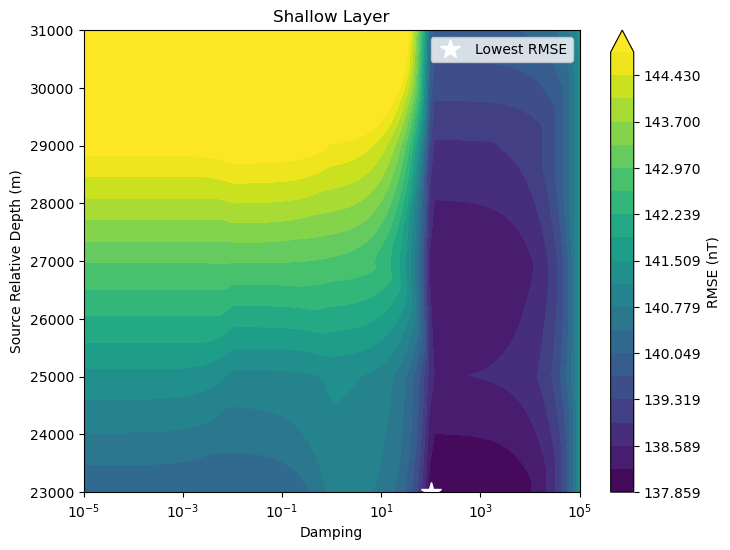

In [21]:
damping_values_shallow = np.array(damping_shallow)
depth_values_shallow = np.array(source_depth_shallow)
score_values_shallow = np.array(scores_shallow)

best_shallow = np.argmin(score_values_shallow)
best_damping_shallow = damping_values_shallow[best_shallow]
best_depth_shallow = depth_values_shallow[best_shallow]
best_rmse_shallow = score_values_shallow[best_shallow]
best_params_shallow = parameter_sets_shallow[best_shallow]
print("Best parameters:", best_params_shallow)
print(f"Best RMSE: {best_rmse_shallow:.3f} nT")

x_shallow = np.logspace(np.log10(damping_values_shallow.min()), np.log10(damping_values_shallow.max()), 100)
y_shallow = np.linspace(depth_values_shallow.min(), depth_values_shallow.max(), 100)
X_shallow, Y_shallow = np.meshgrid(x_shallow, y_shallow)

Z_shallow = griddata(
    (damping_values_shallow, depth_values_shallow),
    score_values_shallow,
    (X_shallow, Y_shallow),
    method='linear'
)
plt.figure(figsize=(8, 6))
levels_shallow = np.linspace(
    Z_shallow.min(),
    np.nanpercentile(score_values_shallow, 80),
    20,
)
c = plt.contourf(
    X_shallow,
    Y_shallow,
    Z_shallow,
    levels=levels_shallow,
    cmap="viridis",
    extend='max',
)
plt.plot(
    best_damping_shallow,
    best_depth_shallow,
    '*',
    color='white',
    markersize=15,
    label='Lowest RMSE'
)
plt.xscale('log')
plt.xlabel('Damping')
plt.ylabel('Source Relative Depth (m)')
plt.colorbar(c, label='RMSE (nT)')
plt.legend()
plt.title("Shallow Layer")
plt.show()

In [22]:
%%time
eqs_shallow = sph.EquivalentSourcesMagGeodGB(window_size=200e3, **parameter_sets_shallow[best])
eqs_shallow.fit(coordinates, inclination, declination, residuals_deep)
print(eqs_shallow.window_size_)

Output()

200000.0
CPU times: user 27.3 s, sys: 75.7 ms, total: 27.3 s
Wall time: 4.78 s


Plot the predidted and the residuals of the shallow layer, to check if the eqs is good.

In [23]:
predicted_shallow =  hm.total_field_anomaly(eqs_shallow.predict(coordinates), inclination, declination)
residuals_shallow = residuals_deep - predicted_shallow 

predicted_b_shallow = eqs_shallow.predict(coordinates)

residuals_be_shallow = residuals_be_deep - predicted_b_shallow[0]
residuals_bn_shallow = residuals_bn_deep - predicted_b_shallow[1]
residuals_bu_shallow = residuals_bu_deep - predicted_b_shallow[2]

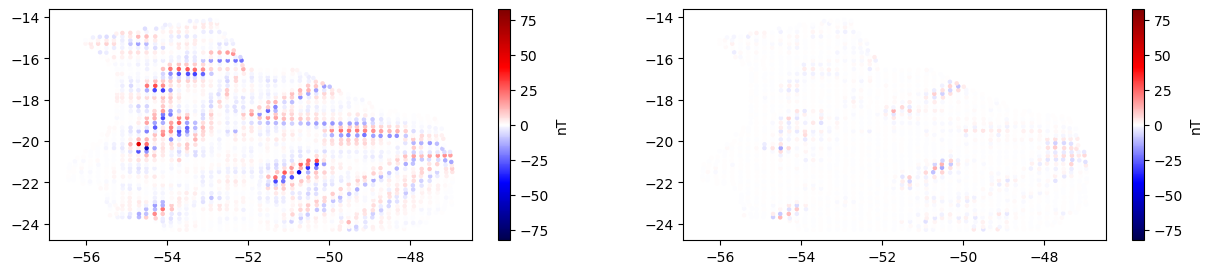

In [24]:
scale_deep = vd.maxabs(predicted_shallow)
plt.figure(figsize=(15,3))


plt.subplot(1,2,1)
plt.scatter(coordinates[0], coordinates[1],c = predicted_shallow, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

plt.subplot(1,2,2)
plt.scatter(coordinates[0], coordinates[1],c = residuals_shallow, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

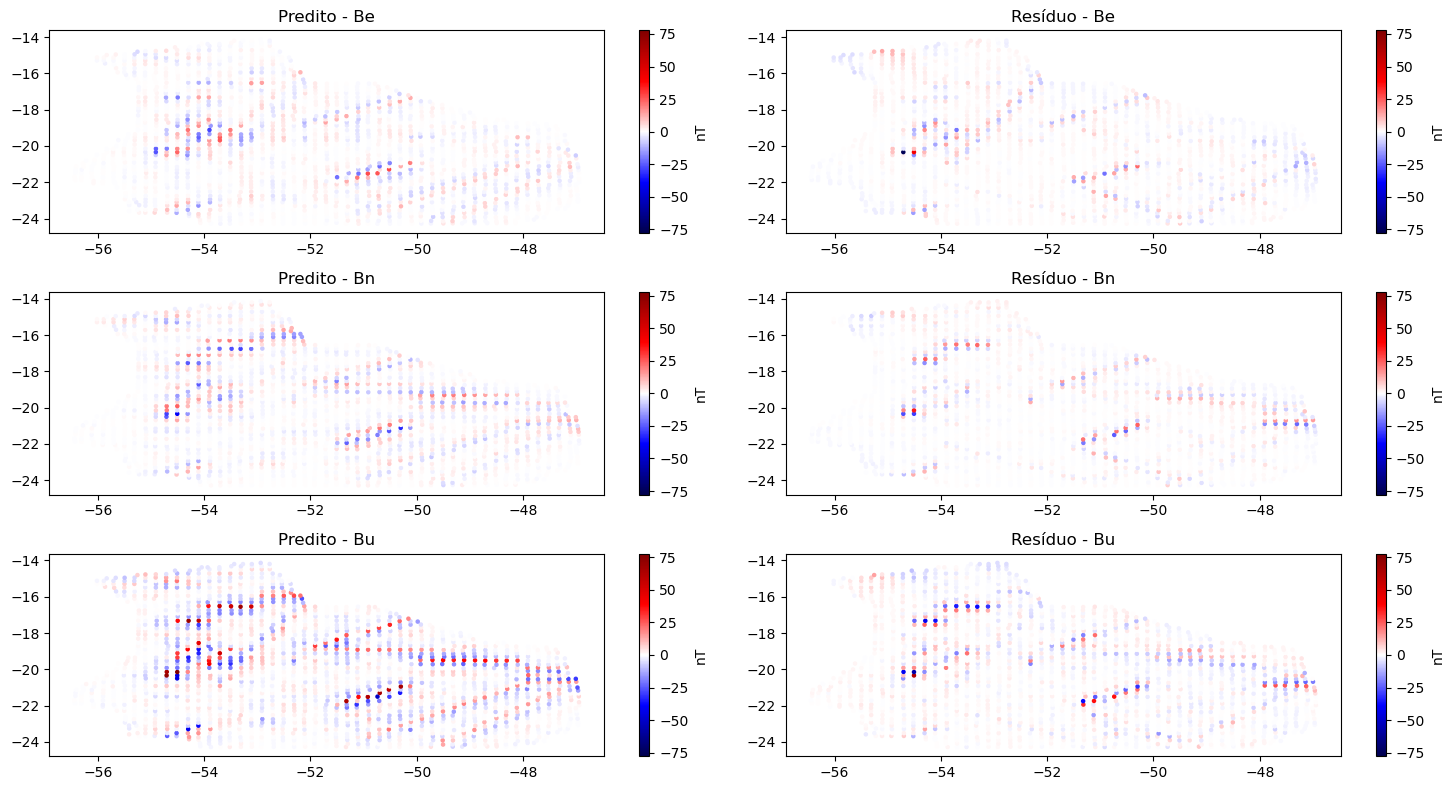

In [25]:
scale_b_shallow = vd.maxabs(predicted_b_shallow)
plt.figure(figsize=(15, 8))

# Componente E
plt.subplot(3, 2, 1)
plt.scatter(coordinates[0], coordinates[1], c=predicted_b_shallow[0], s=5,
            cmap="seismic", vmin=-scale_b_shallow, vmax=scale_b_shallow)
plt.colorbar(label='nT')
plt.title("Predito - Be")

plt.subplot(3, 2, 2)
plt.scatter(coordinates[0], coordinates[1], c=residuals_be_shallow, s=5,
            cmap="seismic", vmin=-scale_b_shallow, vmax=scale_b_shallow)
plt.colorbar(label='nT')
plt.title("Resíduo - Be")

# Componente N
plt.subplot(3, 2, 3)
plt.scatter(coordinates[0], coordinates[1], c=predicted_b_shallow[1], s=5,
            cmap="seismic", vmin=-scale_b_shallow, vmax=scale_b_shallow)
plt.colorbar(label='nT')
plt.title("Predito - Bn")

plt.subplot(3, 2, 4)
plt.scatter(coordinates[0], coordinates[1], c=residuals_bn_shallow, s=5,
            cmap="seismic", vmin=-scale_b_shallow, vmax=scale_b_shallow)
plt.colorbar(label='nT')
plt.title("Resíduo - Bn")

# Componente U
plt.subplot(3, 2, 5)
plt.scatter(coordinates[0], coordinates[1], c=predicted_b_shallow[2], s=5,
            cmap="seismic", vmin=-scale_b_shallow, vmax=scale_b_shallow)
plt.colorbar(label='nT')
plt.title("Predito - Bu")

plt.subplot(3, 2, 6)
plt.scatter(coordinates[0], coordinates[1], c=residuals_bu_shallow, s=5,
            cmap="seismic", vmin=-scale_b_shallow, vmax=scale_b_shallow)
plt.colorbar(label='nT')
plt.title("Resíduo - Bu")

plt.tight_layout()
plt.show()

Predict both on a regular grid and sum.

In [26]:
total_field_anomaly_predicted = vd.make_xarray_grid(
    grid_coord,
    hm.total_field_anomaly(eqs_deep.predict(grid_coord), inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid


total_field_anomaly_predicted += vd.make_xarray_grid(
    grid_coord,
    hm.total_field_anomaly(eqs_shallow.predict(grid_coord), inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

grided_dd_anomaly = vd.make_xarray_grid(
    grid_coord,
    grided_dd_anomaly,
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

In [27]:

b_predicted = vd.make_xarray_grid(
    grid_coord,
    eqs_deep.predict(grid_coord),
    data_names=("be","bn","bu"),
    dims=("latitude", "longitude"),
    extra_coords_names="height",
)

b_predicted+= vd.make_xarray_grid(
    grid_coord,
    eqs_shallow.predict(grid_coord),
    data_names=("be","bn","bu"),
    dims=("latitude", "longitude"),
    extra_coords_names="height",
)

grided_magnetic_field = vd.make_xarray_grid(
    grid_coord,
    magnetic_field_grid,
    data_names=("be","bn","bu"),
    dims=("latitude", "longitude"),
    extra_coords_names="height",
)

Plot the total field anomaly predicted, the true total field anomaly and the difference.

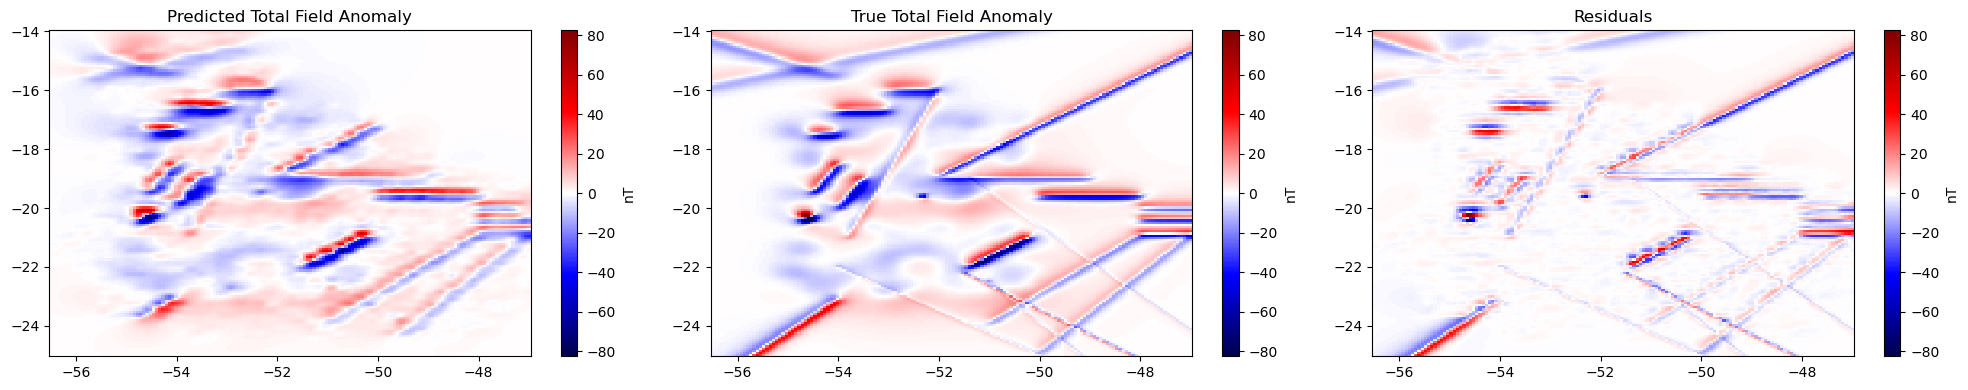

In [28]:
diff_grid_tfa = grided_dd_anomaly -  total_field_anomaly_predicted

plt.figure(figsize=(20,4))

plt.subplot(1,3,1)
plt.title("Predicted Total Field Anomaly")
plt.pcolormesh(
    *grid_coord[:2], total_field_anomaly_predicted, cmap="seismic", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')


plt.subplot(1,3,2)
plt.title("True Total Field Anomaly")
plt.pcolormesh(
    *grid_coord[:2], grided_dd_anomaly, cmap="seismic", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')


plt.subplot(1,3,3)
plt.title('Residuals')
plt.pcolormesh(
    *grid_coord[:2], diff_grid_tfa, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.tight_layout()

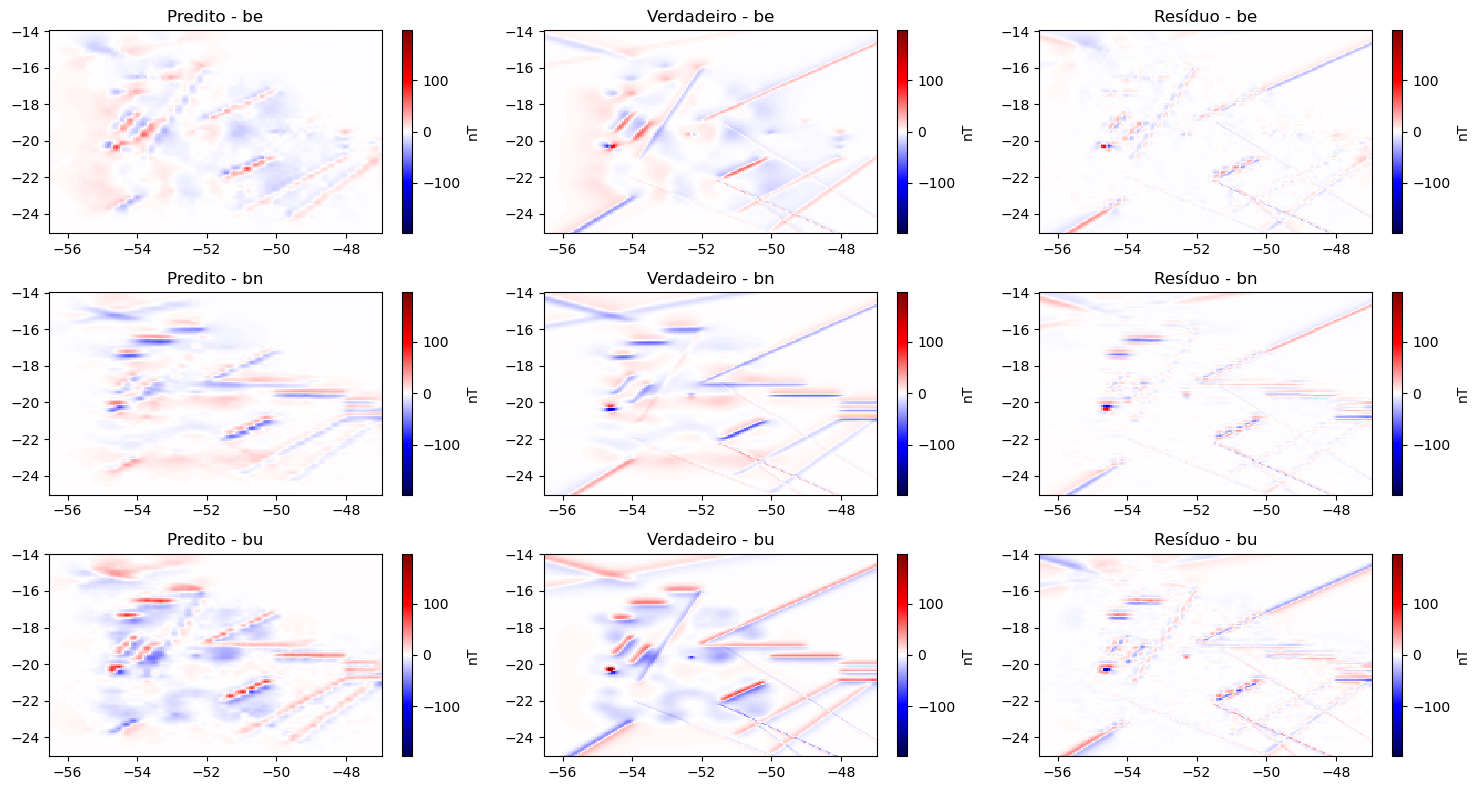

In [29]:

b_diff = b_predicted - grided_magnetic_field

scale = vd.maxabs(b_diff.to_array())

plt.figure(figsize=(15, 8))

plt.subplot(3, 3, 1)
plt.title("Predito - be")
plt.pcolormesh(*grid_coord[:2], b_predicted["be"],
               cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

plt.subplot(3, 3, 2)
plt.title("Verdadeiro - be")
plt.pcolormesh(*grid_coord[:2], grided_magnetic_field["be"],
               cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

plt.subplot(3, 3, 3)
plt.title("Resíduo - be")
plt.pcolormesh(*grid_coord[:2], b_diff["be"],
               cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

# Componente bn
plt.subplot(3, 3, 4)
plt.title("Predito - bn")
plt.pcolormesh(*grid_coord[:2], b_predicted["bn"],
               cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

plt.subplot(3, 3, 5)
plt.title("Verdadeiro - bn")
plt.pcolormesh(*grid_coord[:2], grided_magnetic_field["bn"],
               cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

plt.subplot(3, 3, 6)
plt.title("Resíduo - bn")
plt.pcolormesh(*grid_coord[:2], b_diff["bn"],
               cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

# Componente bu
plt.subplot(3, 3, 7)
plt.title("Predito - bu")
plt.pcolormesh(*grid_coord[:2], b_predicted["bu"],
               cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

plt.subplot(3, 3, 8)
plt.title("Verdadeiro - bu")
plt.pcolormesh(*grid_coord[:2], grided_magnetic_field["bu"],
               cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

plt.subplot(3, 3, 9)
plt.title("Resíduo - bu")
plt.pcolormesh(*grid_coord[:2], b_diff["bu"],
               cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

plt.tight_layout()
plt.show()


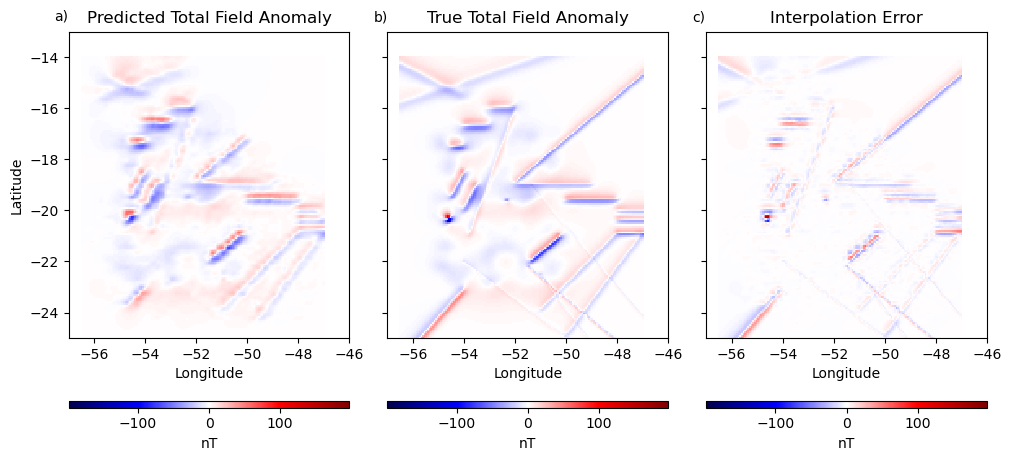

In [30]:
region = [-57, -46, -25, -13]
fig, axes = plt.subplots(1, 3, figsize=(10, 4.5), sharey=True, layout="constrained")  


im0 = axes[0].pcolormesh(*grid_coord[:2], total_field_anomaly_predicted, cmap="seismic", vmin=-scale, vmax=scale)
axes[0].set_title("Predicted Total Field Anomaly")
axes[0].set_ylabel("Latitude")
axes[0].set_aspect("equal")

im1 = axes[1].pcolormesh(*grid_coord[:2], grided_dd_anomaly, cmap="seismic", vmin=-scale, vmax=scale)
axes[1].set_title("True Total Field Anomaly")
axes[1].set_aspect("equal")


diff_grid_tfa = grided_dd_anomaly - total_field_anomaly_predicted
im2 = axes[2].pcolormesh(*grid_coord[:2], diff_grid_tfa, cmap="seismic", vmin=-scale, vmax=scale)
axes[2].set_title(f"Interpolation Error")
axes[2].set_aspect("equal")


cb0 = fig.colorbar(im0, ax=axes[0], orientation="horizontal", aspect=40)
cb0.set_label("nT")
cb1 = fig.colorbar(im1, ax=axes[1], orientation="horizontal", aspect=40)
cb1.set_label("nT")
cb2 = fig.colorbar(im2, ax=axes[2], orientation="horizontal", aspect=40)
cb2.set_label("nT")

for ax in axes.ravel():
    ax.set_xlim(*region[:2])
    ax.set_ylim(*region[2:])
    ax.set_xlabel("Longitude")

for ax, label in zip(axes, "abc"):
    ax.text(-0.05, 1.035, f"{label})", transform=ax.transAxes)

# plt.savefig("total_field_anomaly_inversion-gb.png", dpi=200, format='png')
plt.show()


Use Pooch to dowload the shape files of the Brazilian state division to use in our map

In [31]:
data = pooch.retrieve('https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/Brasil/BR/BR_UF_2022.zip',
               known_hash='md5:de36120dc7867c8c98990db8b727c3f5', fname='BR_UF_2022.zip')

In [32]:
shapefile_brasil = "../../../.cache/pooch//BR_UF_2022/BR_UF_2022.shp"


required_extensions = ['.shp', '.shx', '.dbf']
base_name = os.path.splitext(shapefile_brasil)[0]

missing_files = []
for ext in required_extensions:
    file_path = f"{base_name}{ext}"
    if not os.path.exists(file_path):
        missing_files.append(file_path)

if missing_files:
    print(f"Erro: Os seguintes arquivos obrigatórios estão faltando: {', '.join(missing_files)}")
    exit()


try:
    brasil = gpd.read_file(shapefile_brasil)
except Exception as e:
    print(f"Erro ao carregar o shapefile: {e}")
    exit()


brasil_reduc = brasil.simplify(0.05)

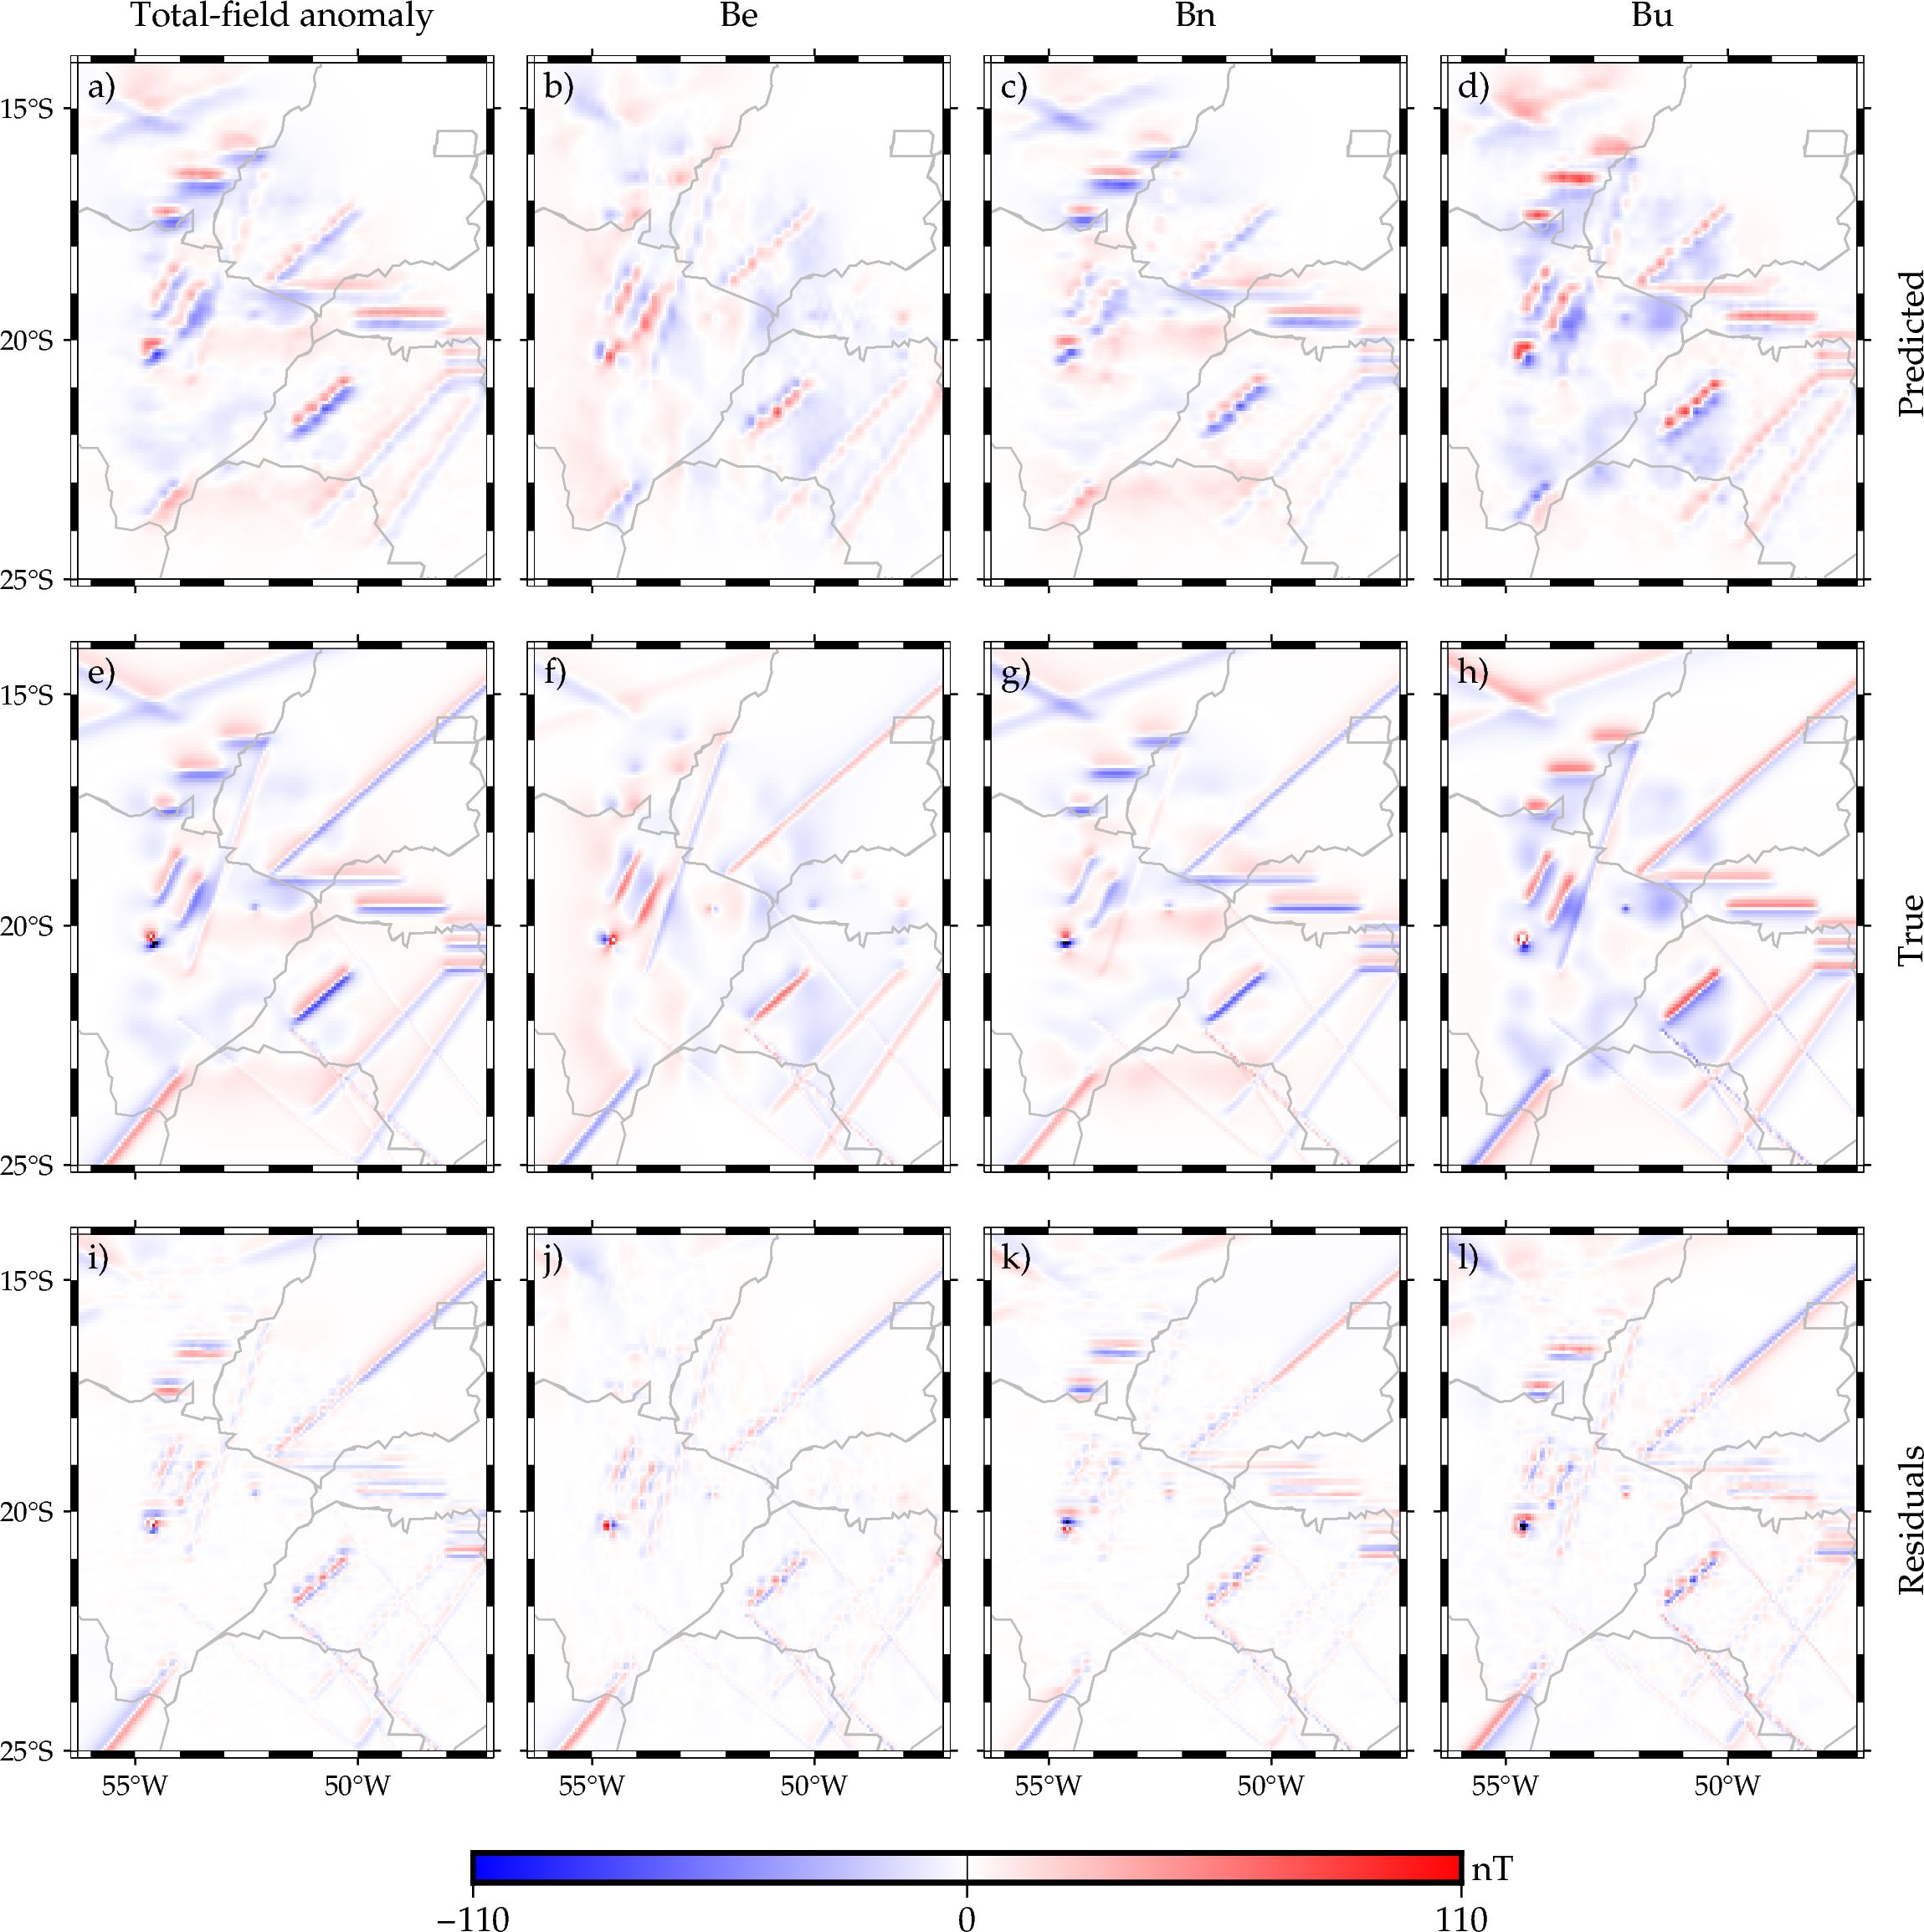

In [34]:
region = [-56.3, -47.1, -25, -14]
scale = 110
fig = pygmt.Figure()

grids = [
    total_field_anomaly_predicted, 
    b_predicted["be"], 
    b_predicted["bn"], 
    b_predicted["bu"], 
    grided_dd_anomaly, 
    grided_magnetic_field["be"], 
    grided_magnetic_field["bn"], 
    grided_magnetic_field["bu"], 
    diff_grid_tfa, 
    b_diff["be"], 
    b_diff["bn"], 
    b_diff["bu"]
]

with pygmt.config(FONT="10p,Palatino-Roman", 
    FONT_ANNOT="8p,Palatino-Roman",
    FONT_ANNOT_PRIMARY="8p,Palatino-Roman",
    FONT_ANNOT_SECONDARY="8p,Palatino-Roman",
    MAP_FRAME_WIDTH="1.0p",
    MAP_TITLE_OFFSET="-2.0p", ):

    pygmt.makecpt(cmap="polar", series=[-scale, scale])

    with fig.subplot(nrows=3, 
            ncols=4, 
            figsize=("18c", "17.5c"), 
            autolabel="+jTL+o0.1/0.3c", 
            margins='0.1c/0', 
            sharex="b", 
            sharey="l"):
        for i, grid in enumerate(grids):
            with fig.set_panel(panel=i):
                with pygmt.config(MAP_FRAME_WIDTH="2.0p",):                                                

                    fig.grdimage(
                        grid=grid,
                        region=region,
                        projection="M?",
                        cmap=True,
                    )
                    
                    fig.plot(
                        data=brasil_reduc.geometry,
                        pen=".5p,grey",  
                        fill=None,
                        projection="M?",
                        frame = ["a42f"]
                    )
                    
                    if i in [0, 1, 2, 3]:
                        titles = { 
                            0: "Total-field anomaly", 
                            1: "Be", 
                            2: "Bn", 
                            3: "Bu",
                        }
                        fig.basemap(frame=f"+t{titles[i]}")



    fig.text(x=7.3, y=5.69, text="Predicted", angle=90, no_clip=True, font='10p')
    fig.text(x=7.3, y=3.35, text="True", angle=90, no_clip=True, font='10p')
    fig.text(x=7.3, y=1.0, text="Residuals", angle=90, no_clip=True, font='10p')
    
pygmt.config(FONT_ANNOT_PRIMARY="10p,Palatino-Roman", FONT_ANNOT_SECONDARY="10p,Palatino-Roman")
fig.colorbar(position="JBC+w10c/0.3c+h", frame=["y+lnT"])
fig.show(width=1000)
fig.savefig(fname='../paper/figures/grided-TFA-B.jpeg',transparent=False)

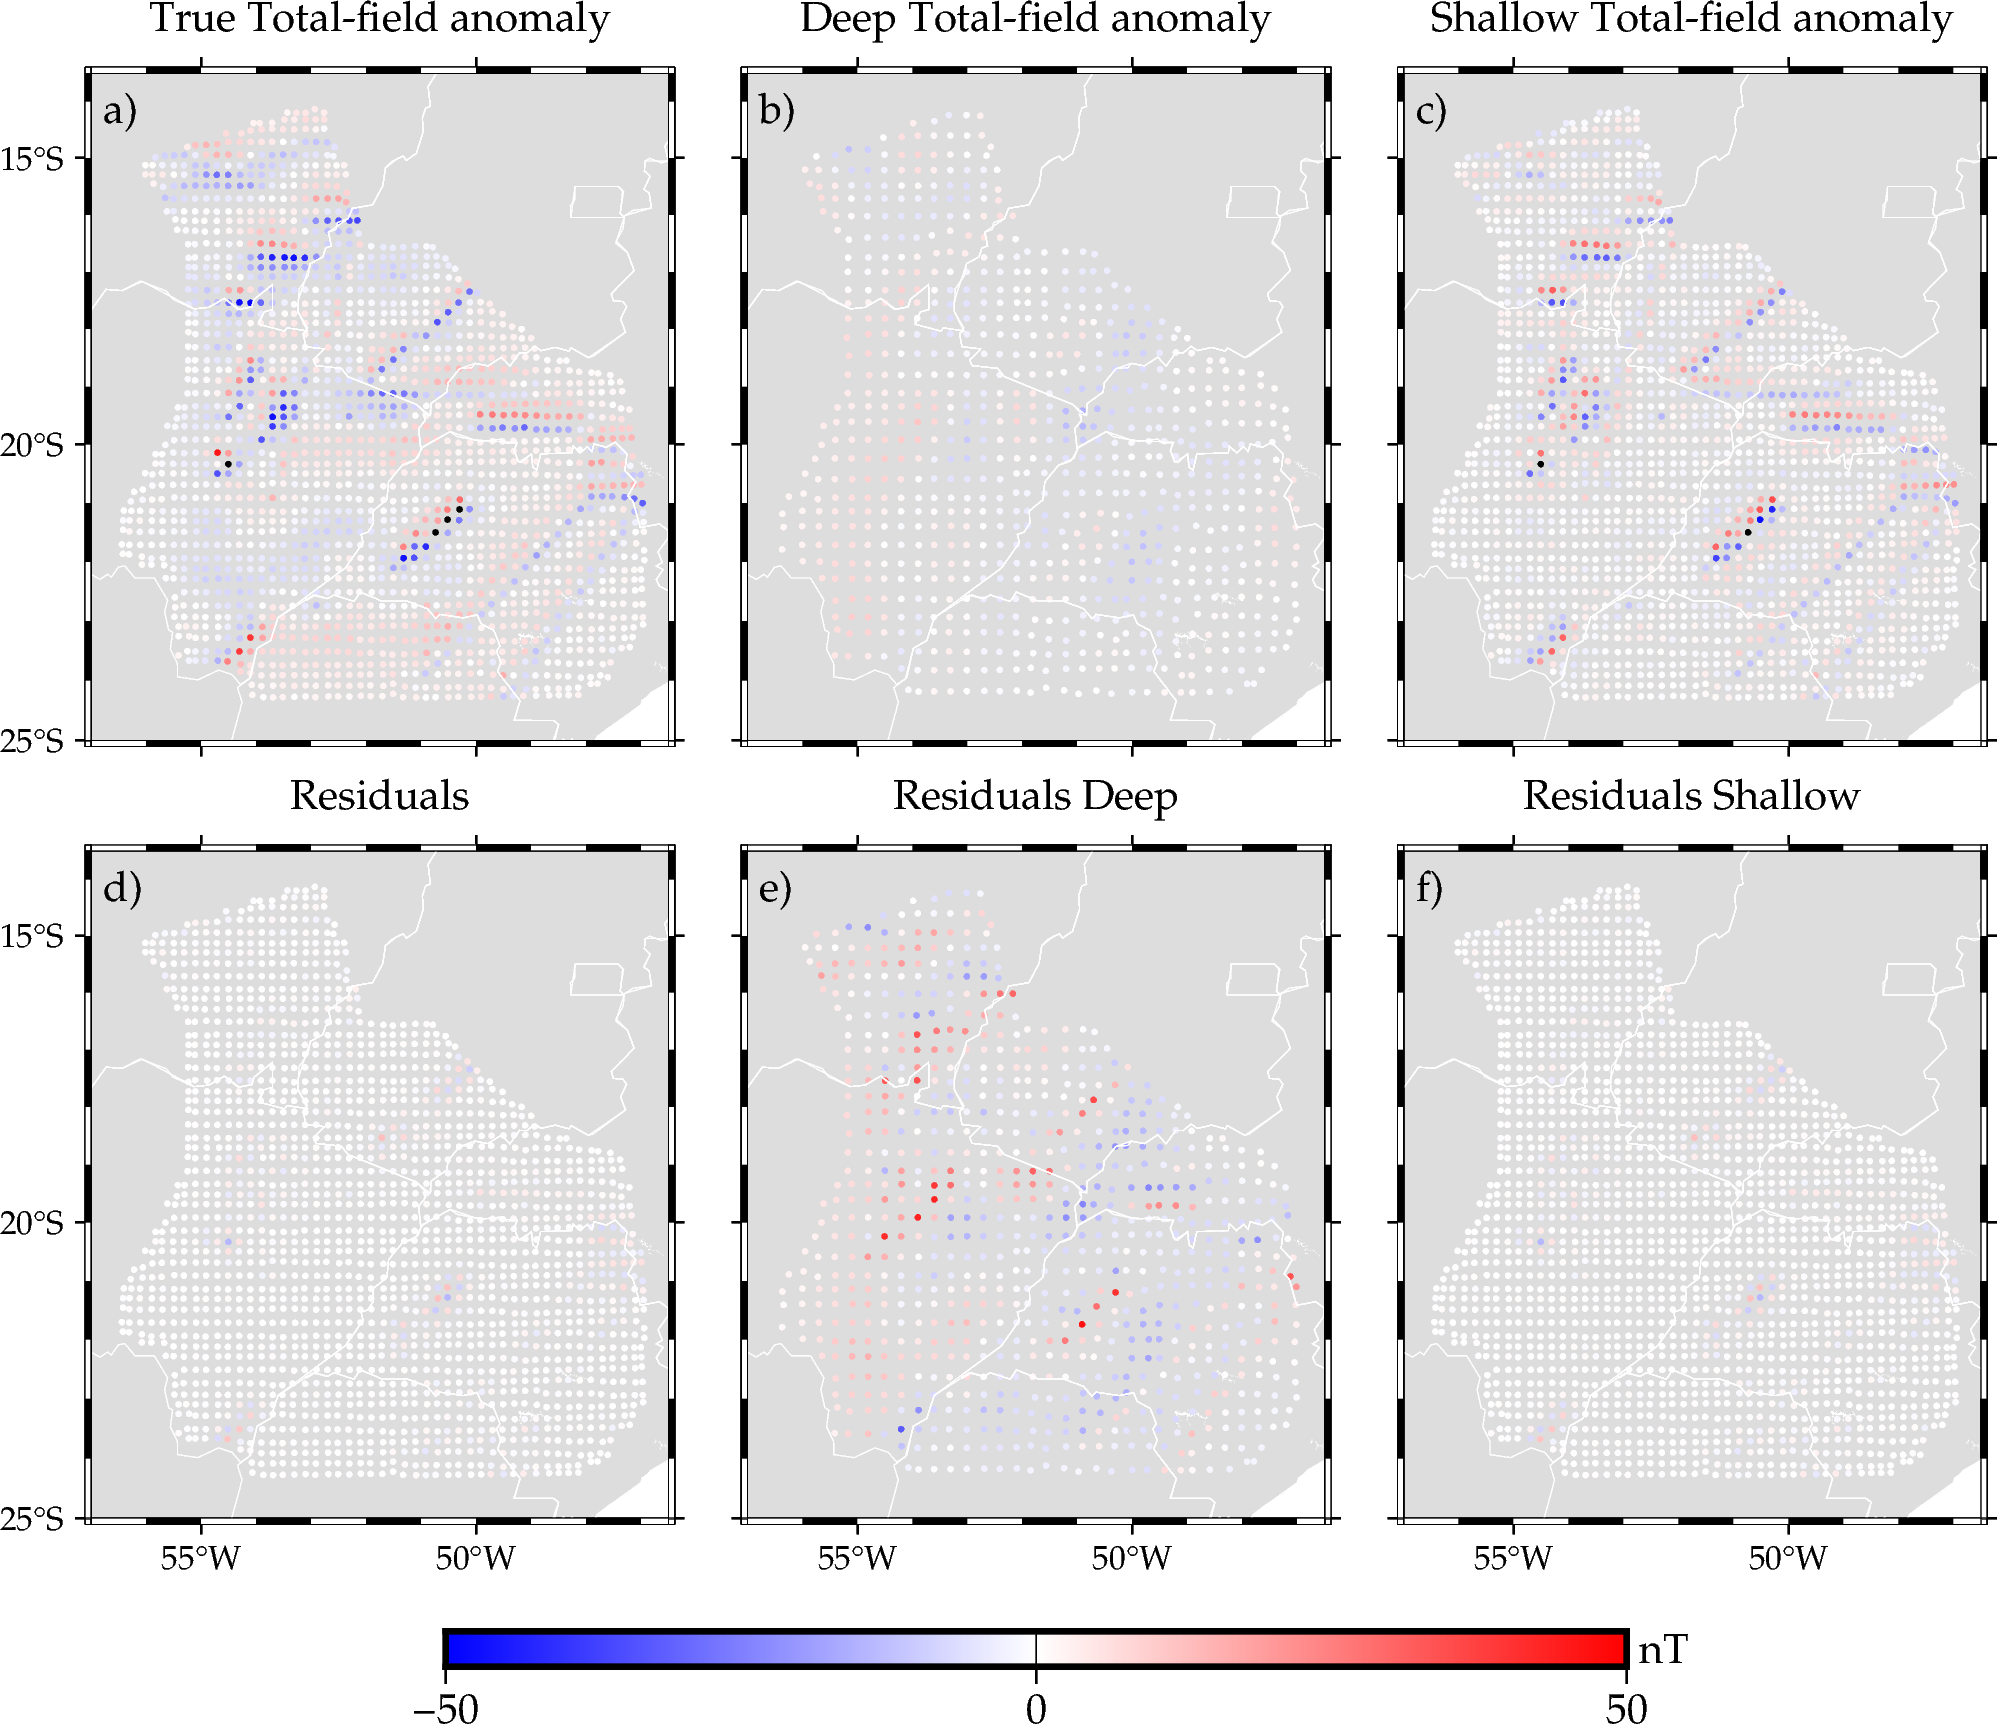

In [35]:
residuals_tfa = magnetic_anomaly - (predicted_deep + predicted_shallow)
shallow = magnetic_anomaly - predicted_deep
residuals_blocked_deep = predicted_blocked_deep - magnetic_anomaly_reduced


plot_data = [
    (magnetic_anomaly, coordinates[0], coordinates[1], "True Total-field anomaly"),
    (predicted_blocked_deep[0], blocked_deep_equivalent_sources[0], blocked_deep_equivalent_sources[1], "Deep Total-field anomaly"),
    (shallow, coordinates[0], coordinates[1], "Shallow Total-field anomaly"),
    (residuals_tfa, coordinates[0], coordinates[1], "Residuals"),
    (residuals_blocked_deep[0], blocked_deep_equivalent_sources[0], blocked_deep_equivalent_sources[1], "Residuals Deep"),
    (residuals_shallow, coordinates[0], coordinates[1], "Residuals Shallow")
]

region = [-57, -46.5, -25, -13.5]
scale = 50
fig = pygmt.Figure()

with pygmt.config(FONT="10p,Palatino-Roman",
    FONT_ANNOT="8p,Palatino-Roman",
    FONT_ANNOT_PRIMARY="8p,Palatino-Roman",
    FONT_ANNOT_SECONDARY="8p,Palatino-Roman",
    MAP_FRAME_WIDTH="1.5p",
    MAP_TITLE_OFFSET="-2p", ):

    pygmt.makecpt(cmap="polar", series=[-scale, scale])

    with fig.subplot(nrows=2,
            ncols=3,
            figsize=("16c", "12.5c"),
            autolabel="+jTL+o0.1/0.3c",
            margins='0.2c/.2c',
            sharex="b",
            sharey="l"):

        for i, (data, x_coords, y_coords, title) in enumerate(plot_data):
            with fig.set_panel(panel=i):

                fig.coast(
                    land="#dddddd",
                    region = region,
                    projection="M?",
                )
                fig.plot(
                    x=x_coords,
                    y=y_coords,
                    fill=data,
                    style="c0.05c",
                    projection="M?",
                    cmap=True
                )

                fig.plot(
                    data=brasil_reduc.geometry,
                    pen=".2p,white",
                    fill=None,
                    projection="M?",
                    frame=["a42f"]
                )

                fig.basemap(frame=f"+t{title}")

pygmt.config(FONT_ANNOT_PRIMARY="10p,Palatino-Roman", FONT_ANNOT_SECONDARY="10p,Palatino-Roman")
fig.colorbar(position="JBC+w10/0.3c+h", frame=["y+lnT"])
fig.show(width=1000)
fig.savefig(fname='../paper/figures/points-TFA-deep-shallow.jpeg',transparent=False)